(100, 2)


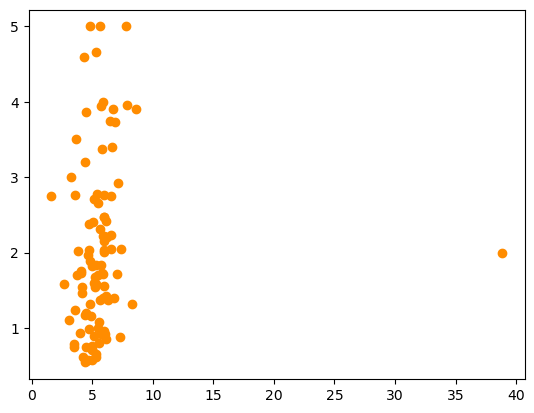

In [6]:
# california에서 2개의 피쳐만 추출해서 시각화하기

import pandas as pd
import numpy as np
import warnings
from sklearn.datasets import fetch_california_housing # fetch_california_housing으로 변경
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# 1. 캘리포니아 주택 데이터 세트 로드
housing = fetch_california_housing()
housingDF = pd.DataFrame(housing.data, columns=housing.feature_names)
housingDF['PRICE'] = housing.target

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

housingDF_sample = housingDF[['AveRooms', 'PRICE']]
housingDF_sample = housingDF_sample.sample(n=100, random_state=0)
print(housingDF_sample.shape)
plt.figure()
plt.scatter(housingDF_sample.AveRooms, housingDF_sample.PRICE, c="darkorange")

In [7]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor # 임포트 확인

# 1. 선형 회귀와 결정 트리 기반의 Regressor 생성 (max_depth 2, 7)
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

# 2. 테스트용 데이터 셋 생성 (AveRooms 범위에 맞춰 조정 가능하나 일단 유지)
X_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# 3. 캘리포니아 샘플 데이터에서 AveRooms와 PRICE 추출
# RM -> AveRooms로 변경
X_feature = housingDF_sample['AveRooms'].values.reshape(-1,1)
y_target = housingDF_sample['PRICE'].values.reshape(-1,1)

# 4. 학습과 예측 수행
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_rf2 = rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

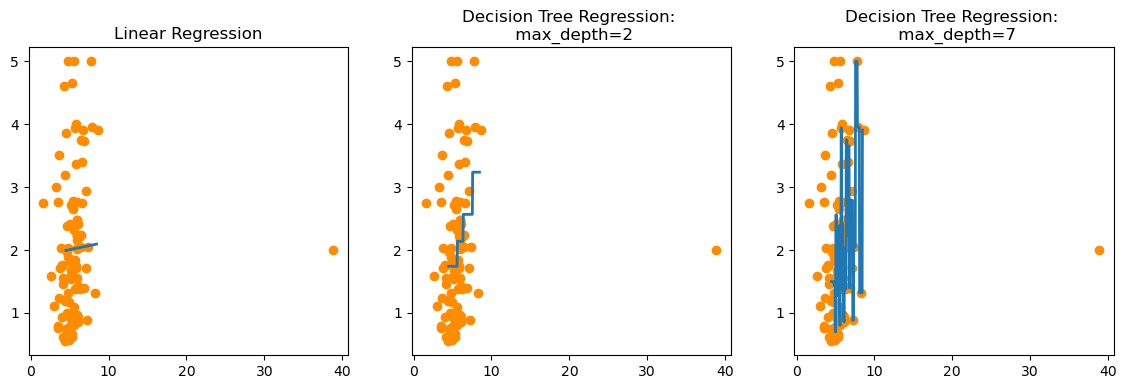

In [8]:
# 그래프 그리는 걸로 마무리

fig , (ax1, ax2, ax3) = plt.subplots(figsize=(14,4), ncols=3)

# 1. 선형 회귀: 데이터의 전체적인 흐름을 직선으로 파악
ax1.set_title('Linear Regression')
ax1.scatter(housingDF_sample.AveRooms, housingDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr, label="linear", linewidth=2)

# 2. 결정 트리 (max_depth=2): 데이터를 크게 몇 단계로만 나누어 예측 (계단 모양)
ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(housingDF_sample.AveRooms, housingDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label="max_depth:2", linewidth=2)

# 3. 결정 트리 (max_depth=7): 데이터 하나하나에 너무 민감하게 반응 (과적합 위험)
ax3.set_title('Decision Tree Regression: \n max_depth=7')
ax3.scatter(housingDF_sample.AveRooms, housingDF_sample.PRICE, c="darkorange")
ax3.plot(X_test, pred_rf7, label="max_depth:7", linewidth=2)

plt.show()